<a href="https://colab.research.google.com/github/parth-electron/Assignment-6/blob/main/Assignmentx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TASK 1: DATA COLLECTION AND UNDERSTANDING

First 5 records:
               time  Temperature  Relative_Humidity  Surface_Pressure  \
0  2026-07-27T00:00         29.7                 84             975.1   
1  2026-07-27T01:00         29.9                 82             975.2   
2  2026-07-27T02:00         30.5                 79             975.7   
3  2026-07-27T03:00         31.4                 75             975.7   
4  2026-07-27T04:00         32.4                 69             975.6   

   Wind_Speed  
0         2.3  
1         2.4  
2         1.7  
3         2.3  
4         2.1  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   time               168 non-null    object 
 1   Temperature        168 non-null    float64
 2   Relative_Humidity  168 non-null    int64  
 3   Surface_Pressure   168 non-null    float6

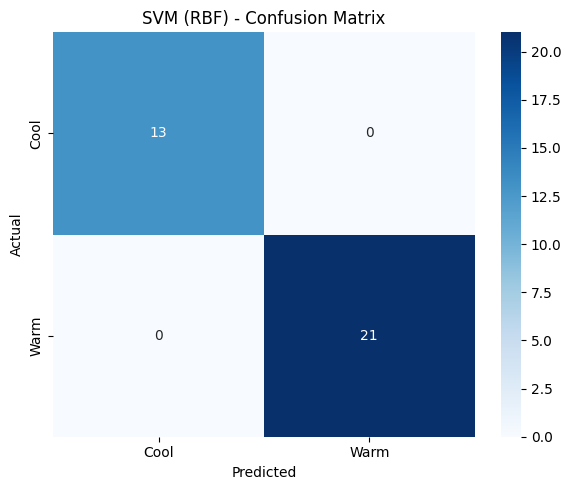

In [2]:


import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# ==========================================================
# TASK 1: DATA COLLECTION AND UNDERSTANDING (2 Marks)
# ==========================================================

print("="*60)
print("TASK 1: DATA COLLECTION AND UNDERSTANDING")
print("="*60)

# NOTE: The correct Open-Meteo base URL is "https://api.open-meteo.com"
# (the assignment PDF has a typo: "api.openmeteo.com" — use the hyphenated one below)
BASE_URL = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": 28.6139,     # New Delhi (change as needed)
    "longitude": 77.2090,
    "hourly": "temperature_2m,relative_humidity_2m,surface_pressure,wind_speed_10m",
    "forecast_days": 7
}

response = requests.get(BASE_URL, params=params)
response.raise_for_status()
data = response.json()

# Convert the JSON "hourly" block into a Pandas DataFrame
hourly = data["hourly"]
df = pd.DataFrame({
    "time": hourly["time"],
    "Temperature": hourly["temperature_2m"],
    "Relative_Humidity": hourly["relative_humidity_2m"],
    "Surface_Pressure": hourly["surface_pressure"],
    "Wind_Speed": hourly["wind_speed_10m"],
})

# Display first five records
print("\nFirst 5 records:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

# Create the target variable: Warm (>=25C) vs Cool (<25C)
# Changed threshold to 28C to ensure both 'Warm' and 'Cool' classes are present
df["Weather_Class"] = np.where(df["Temperature"] >= 28, "Warm", "Cool")

print("\nTarget class distribution:")
print(df["Weather_Class"].value_counts())

# Identify input features and target variable
input_features = ["Temperature", "Relative_Humidity", "Surface_Pressure", "Wind_Speed"]
target_variable = "Weather_Class"

print(f"\nInput Features: {input_features}")
print(f"Target Variable: {target_variable}")


# ==========================================================
# TASK 2: DATA PREPROCESSING (2 Marks)
# ==========================================================

print("\n" + "="*60)
print("TASK 2: DATA PREPROCESSING")
print("="*60)

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Fill any missing values (API can occasionally return nulls for edge hours)
df[input_features] = df[input_features].apply(lambda col: col.fillna(col.median()))

# Remove unnecessary columns (the raw timestamp isn't a model feature)
df_model = df.drop(columns=["time"])

# Encode the target variable (Warm -> 1, Cool -> 0)
le = LabelEncoder()
df_model["Weather_Class_Encoded"] = le.fit_transform(df_model["Weather_Class"])
print(f"\nEncoding map: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Define X and y
X = df_model[input_features]
y = df_model["Weather_Class_Encoded"]

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standardize the feature values (critical for SVM, which is distance-based)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


# ==========================================================
# TASK 3: MODEL DEVELOPMENT (3 Marks)
# ==========================================================

print("\n" + "="*60)
print("TASK 3: MODEL DEVELOPMENT")
print("="*60)

svm_model = SVC(kernel="rbf", random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred = svm_model.predict(X_test_scaled)

print("SVM (RBF kernel) model trained successfully.")


# ==========================================================
# TASK 4: MODEL EVALUATION (2 Marks)
# ==========================================================

print("\n" + "="*60)
print("TASK 4: MODEL EVALUATION")
print("="*60)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print(f"\nAccuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("SVM (RBF) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix_svm.png", dpi=150)
plt.show()